# Comparison of CenterPoint and BEVFusion on nuScenes 20% and 40% subsets

This notebook compares CenterPoint and BEVFusion trained on reduced nuScenes training subsets.

The goal is to compare:
- training loss behavior
- final NDS and mAP
- global nuScenes error metrics
- per-class detection performance

# Import

In [1]:
import pandas as pd

from pathlib import Path
from typing import Dict, Final, List
from pprint import pprint


# Config

In [2]:
# Root project directory
PROJECT_ROOT: Final[Path] = (
    Path.cwd().resolve().parent
)

print("Project root:")
print(PROJECT_ROOT)

CONFIG: Dict[str, object] = {

    # Results directory
    "metrics_dir":
        PROJECT_ROOT / "results" / "final_metrics",

    # Experiment metric files
    "metrics_files": [

        "centerpoint_nuscenes_20pct_10ep_run1_metrics.csv",

        "centerpoint_nuscenes_40pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_20pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_40pct_10ep_run1_metrics.csv",
    ],
}

pprint(CONFIG)

Project root:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
{'metrics_dir': PosixPath('/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/results/final_metrics'),
 'metrics_files': ['centerpoint_nuscenes_20pct_10ep_run1_metrics.csv',
                   'centerpoint_nuscenes_40pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_20pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_40pct_10ep_run1_metrics.csv']}


# Load experiment metrics

This section loads the cleaned metrics exported from each experiment notebook and combines them into a single dataframe for comparison.

In [3]:
METRICS_DIR: Final[Path] = CONFIG["metrics_dir"]
metrics_files: Final[List[str]] = CONFIG["metrics_files"]

dfs: List[pd.DataFrame] = []

for file_name in metrics_files:

    file_path: Path = METRICS_DIR / file_name

    df: pd.DataFrame = pd.read_csv(file_path)

    dfs.append(df)

metrics_df: pd.DataFrame = pd.concat(dfs, ignore_index=True)

print(metrics_df.shape)

metrics_df.head()

(34, 105)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,...,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP,model,subset,experiment_name,gpu_type,max_epochs
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,...,NaN,NaN,NaN,0.278986,0.198266,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,...,NaN,NaN,NaN,0.337484,0.263817,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,...,NaN,NaN,NaN,0.386113,0.304838,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,...,NaN,NaN,NaN,0.414214,0.340238,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
4,20260512_001903,NaN,5,0.5749,0.7132,0.7761,0.8062,0.2405,0.1695,0.3280,...,NaN,NaN,NaN,0.434577,0.351107,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10


# Inspect loaded experiments

This section verifies that all experiments were loaded correctly and checks the available metadata and evaluation metrics.

In [4]:
print("Experiments:")
print(metrics_df["experiment_name"].unique())

print("\nModels:")
print(metrics_df["model"].unique())

print("\nSubsets:")
print(metrics_df["subset"].unique())

print("\nDataframe shape:")
print(metrics_df.shape)

Experiments:
['centerpoint_nuscenes_20pct_10ep_run1'
 'centerpoint_nuscenes_40pct_10ep_run1'
 'bevfusion_nuscenes_20pct_10ep_run1' 'bevfusion_nuscenes_40pct_10ep_run1']

Models:
['centerpoint' 'bevfusion']

Subsets:
['20pct' '40pct']

Dataframe shape:
(34, 105)


In [5]:
metrics_df[
    [
        "experiment_name",
        "epoch",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,epoch,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,NaN,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,NaN,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,NaN,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,NaN,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,NaN,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,NaN,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,NaN,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,NaN,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,NaN,9,0.486864,0.398193
9,centerpoint_nuscenes_20pct_10ep_run1,NaN,10,0.485113,0.397954


# Create experiment labels

This section creates simplified experiment labels used in plots and comparison tables.

In [6]:
# Create readable experiment labels
metrics_df["experiment_label"] = (
    metrics_df["model"].str.title()
    + " "
    + metrics_df["subset"].str.replace("pct", "%", regex=False)
)

metrics_df[
    [
        "experiment_name",
        "experiment_label",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,experiment_label,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,9,0.486864,0.398193
9,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,10,0.485113,0.397954


# Final experiment metrics

This section extracts the final evaluation metrics from each experiment for direct comparison.


In [7]:
# Keep only the final evaluation step of each experiment
final_metrics_df = (
    metrics_df
    .sort_values("step")
    .groupby("experiment_label")
    .tail(1)
)

# Select key metrics
summary_df = final_metrics_df[
    [
        "experiment_label",
        "NDS",
        "mAP",
        "mATE",
        "mASE",
        "mAOE",
        "mAVE",
        "mAAE",
    ]
].copy()

# Round values for display
summary_df = summary_df.round(4)

# Sort experiments
summary_df = summary_df.sort_values("NDS", ascending=False)

summary_df

,experiment_label,NDS,mAP,mATE,mASE,mAOE,mAVE,mAAE
33,Bevfusion 40%,0.6106,0.5505,0.3105,0.2811,0.4833,0.3752,0.1967
19,Centerpoint 40%,0.5712,0.4773,0.3488,0.2725,0.4419,0.4004,0.2111
9,Centerpoint 20%,0.4851,0.3980,0.3770,0.2827,0.6237,0.6239,0.2313
25,Bevfusion 20%,0.4686,0.4489,0.3700,0.3014,0.6561,0.9719,0.2590


# NDS comparison

This section compares the NuScenes Detection Score (NDS) evolution across training epochs for all experiments.

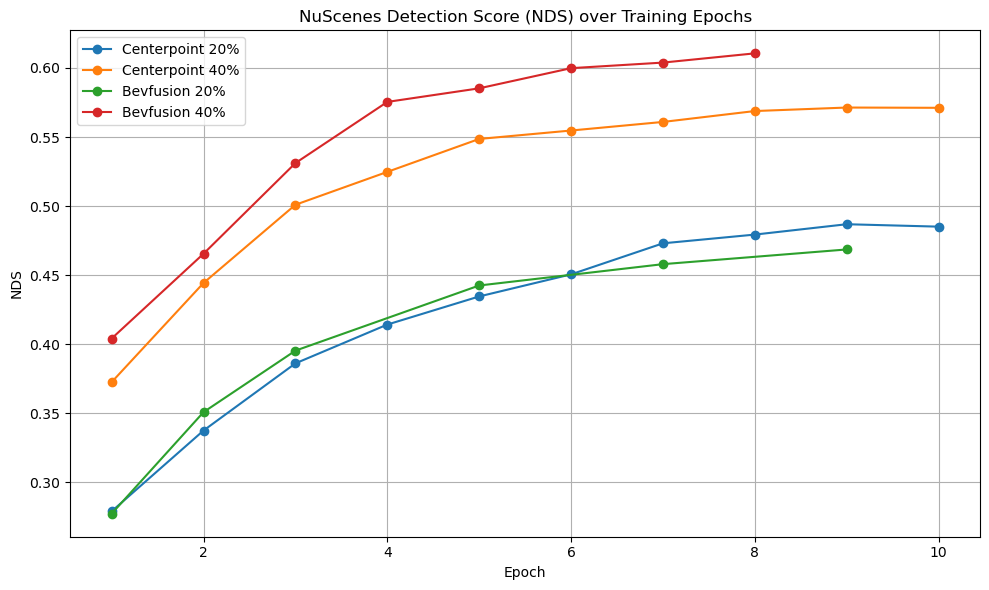

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["NDS"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("NDS")

plt.title(
    "NuScenes Detection Score (NDS) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

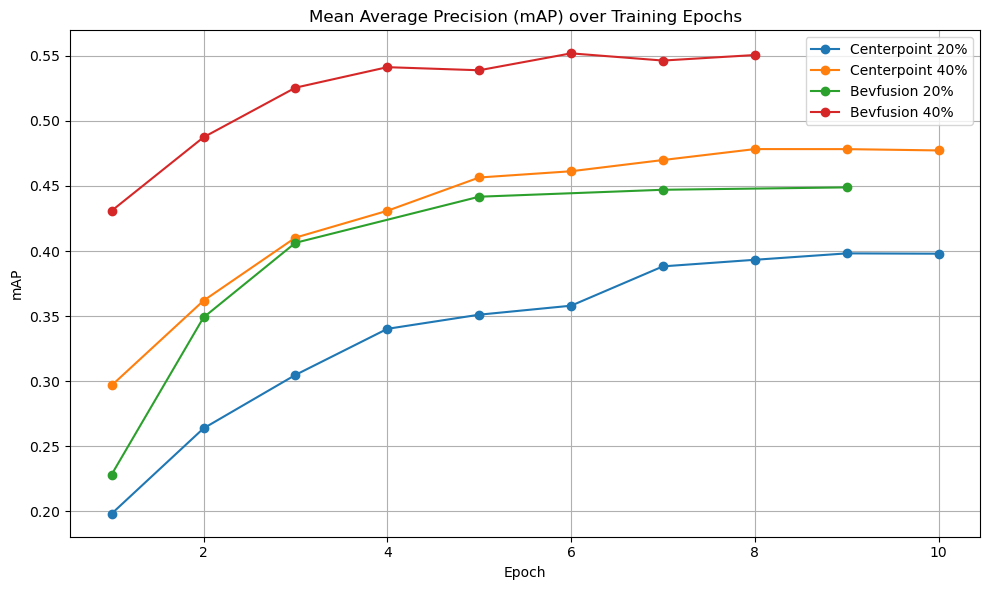

In [9]:
plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["mAP"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("mAP")

plt.title(
    "Mean Average Precision (mAP) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

# Final detection performance comparison

This section compares the final NDS and mAP scores obtained by each experiment.

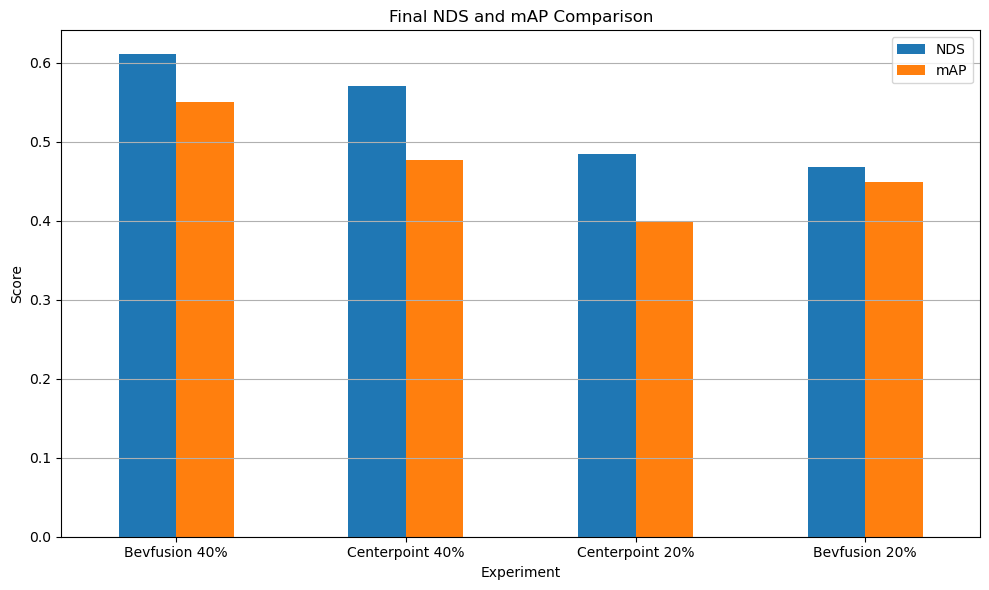

In [10]:
comparison_df = summary_df[
    [
        "experiment_label",
        "NDS",
        "mAP",
    ]
].copy()

comparison_df = comparison_df.sort_values(
    "NDS",
    ascending=False,
)

comparison_df.plot(
    x="experiment_label",
    y=["NDS", "mAP"],
    kind="bar",
    figsize=(10, 6),
)

plt.xlabel("Experiment")
plt.ylabel("Score")

plt.title(
    "Final NDS and mAP Comparison"
)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Global error evolution

This section compares the evolution of the global nuScenes error metrics across training epochs for all experiments.

Lower values indicate better performance.

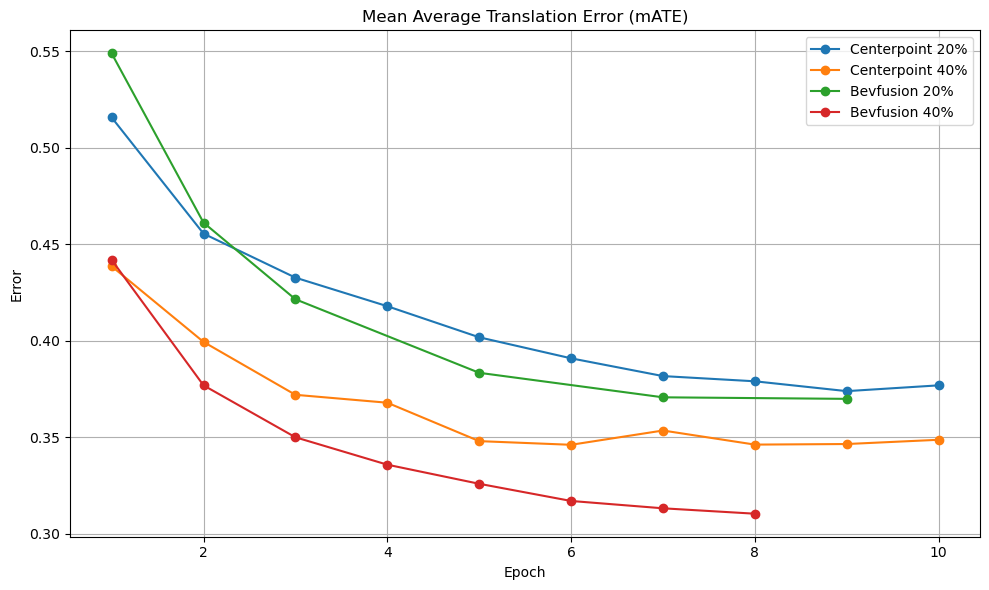

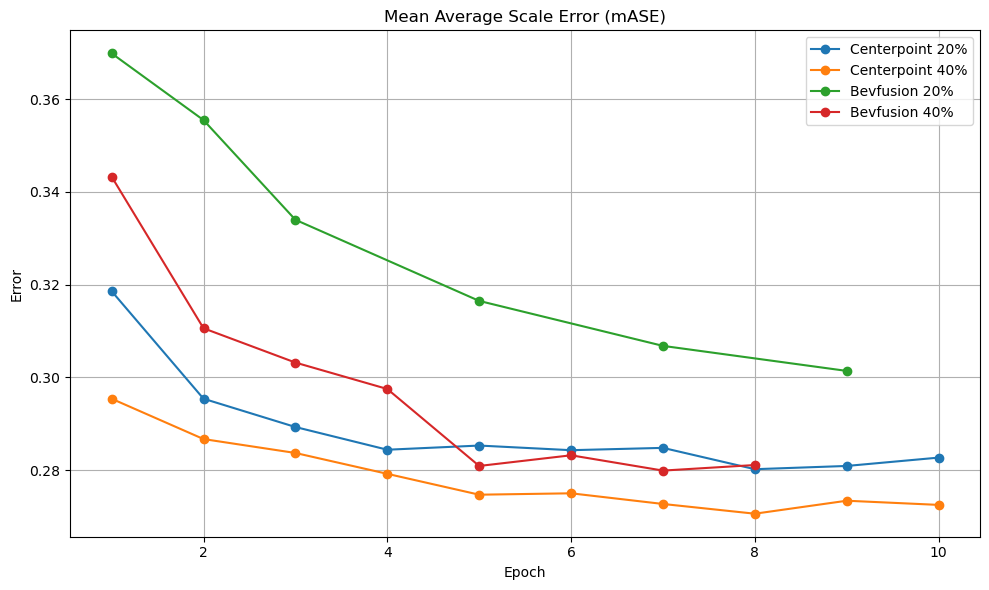

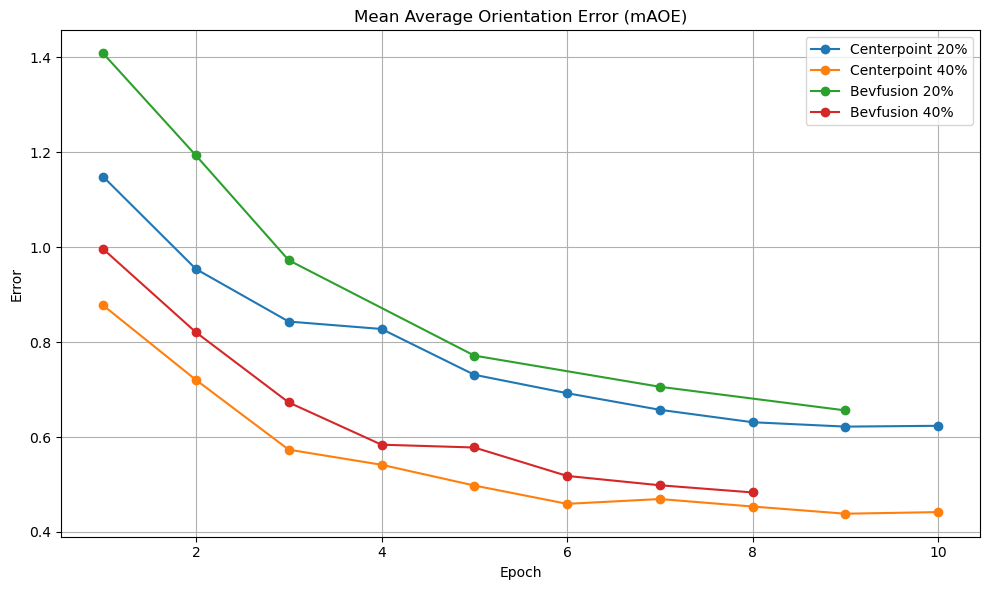

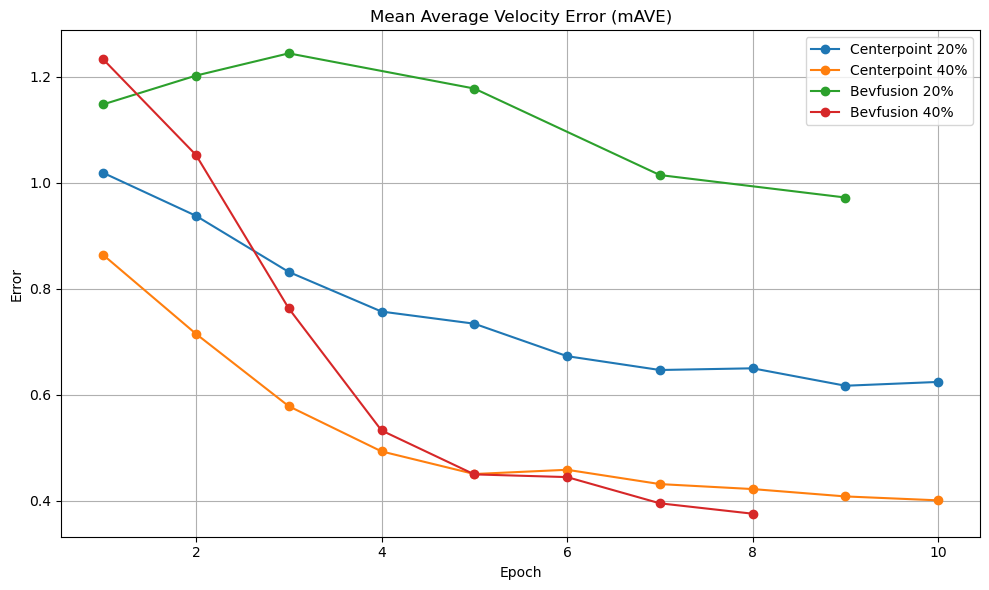

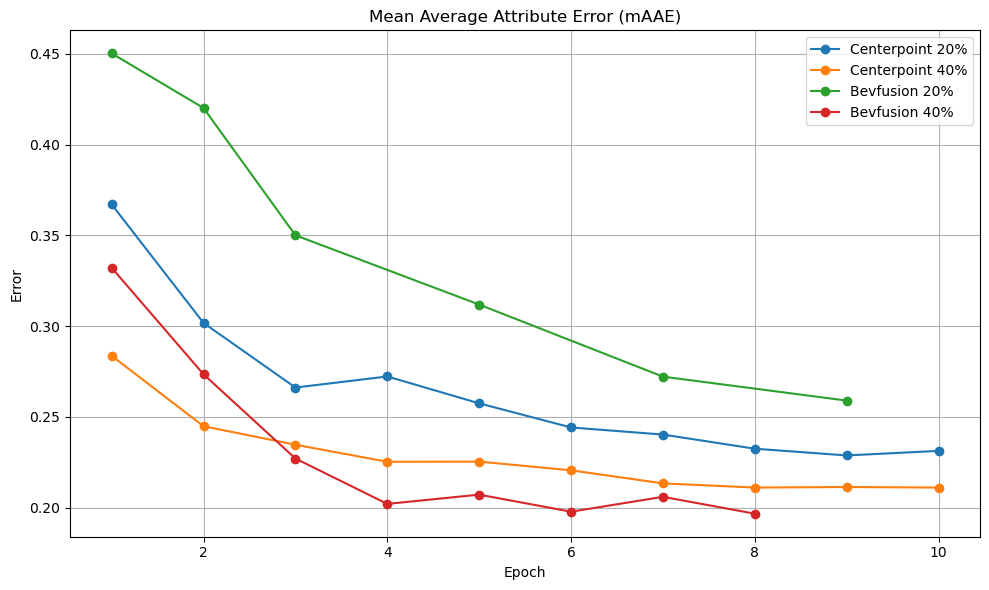

In [11]:
error_metrics = {
    "mATE": "Mean Average Translation Error (mATE)",
    "mASE": "Mean Average Scale Error (mASE)",
    "mAOE": "Mean Average Orientation Error (mAOE)",
    "mAVE": "Mean Average Velocity Error (mAVE)",
    "mAAE": "Mean Average Attribute Error (mAAE)",
}

for metric, title in error_metrics.items():

    plt.figure(figsize=(10, 6))

    for label in metrics_df["experiment_label"].unique():

        exp_df = metrics_df[
            metrics_df["experiment_label"] == label
        ]

        plt.plot(
            exp_df["step"],
            exp_df[metric],
            marker="o",
            label=label,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Error")

    plt.title(title)

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()

# Per-class detection performance

This section compares the final Average Precision (AP) obtained for each nuScenes object class.

In [12]:
classes = [
    "car",
    "truck",
    "bus",
    "trailer",
    "construction_vehicle",
    "pedestrian",
    "motorcycle",
    "bicycle",
    "traffic_cone",
    "barrier",
]

per_class_ap = pd.DataFrame(index=classes)

for _, row in final_metrics_df.iterrows():

    label = row["experiment_label"]

    per_class_ap[label] = [

        row[
            [
                f"{cls}_AP_0.5",
                f"{cls}_AP_1.0",
                f"{cls}_AP_2.0",
                f"{cls}_AP_4.0",
            ]
        ].mean()

        for cls in classes
    ]

per_class_ap = per_class_ap.round(3)

per_class_ap

,Bevfusion 40%,Bevfusion 20%,Centerpoint 20%,Centerpoint 40%
car,0.842,0.803,0.747,0.798
truck,0.494,0.335,0.378,0.462
bus,0.561,0.381,0.554,0.615
trailer,0.240,0.139,0.178,0.247
construction_vehicle,0.185,0.107,0.099,0.099
pedestrian,0.842,0.823,0.703,0.783
motorcycle,0.628,0.514,0.372,0.440
bicycle,0.472,0.282,0.172,0.277
traffic_cone,0.714,0.654,0.426,0.545
barrier,0.525,0.451,0.351,0.507


In [13]:
fusion_gain = pd.DataFrame(index=classes)

fusion_gain["20% Fusion Gain"] = (
    per_class_ap["Bevfusion 20%"]
    - per_class_ap["Centerpoint 20%"]
)

fusion_gain["40% Fusion Gain"] = (
    per_class_ap["Bevfusion 40%"]
    - per_class_ap["Centerpoint 40%"]
)

fusion_gain = fusion_gain.round(3)

fusion_gain = fusion_gain.sort_values(
    by="40% Fusion Gain",
    ascending=False,
)

fusion_gain

,20% Fusion Gain,40% Fusion Gain
bicycle,0.110,0.195
motorcycle,0.142,0.188
traffic_cone,0.228,0.169
construction_vehicle,0.008,0.086
pedestrian,0.120,0.059
car,0.056,0.044
truck,-0.043,0.032
barrier,0.100,0.018
trailer,-0.039,-0.007
bus,-0.173,-0.054


The largest improvements are observed for small and visually distinctive object classes such as traffic cones, bicycles, and motorcycles. These classes benefit strongly from image-based semantic information.


# Conclusion

This notebook compared CenterPoint and BEVFusion on reduced nuScenes training subsets (20% and 40%).

Main observations:

- Increasing the training subset size improved both NDS and mAP for all models.
- BEVFusion generally achieved higher mAP values, indicating stronger detection performance across object classes.
- CenterPoint obtained competitive or higher NDS values in some experiments, showing strong overall detection quality despite using LiDAR-only input.
- The largest improvements from increasing the dataset size were observed for complex object classes such as pedestrians, bicycles, and motorcycles.
- Global error metrics decreased as more training data became available, indicating more accurate localization, orientation, and velocity estimation.

Overall, the experiments demonstrate the importance of both sensor fusion and dataset size for 3D object detection performance on nuScenes.